# Bootstrap Results Small Multiples

This notebook visualizes the bootstrap results as small-multiple dumbbell plots.

- One 2x2 grid is shown for the `original` runs.
- One 2x2 grid is shown for the `complex` runs.
- Each subplot corresponds to one metric.
- Each method is shown as a horizontal CI dumbbell: the line spans the 95% bootstrap interval and the center marker shows the point estimate.


In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='ticks', context='paper')

NOTEBOOK_DIR = Path.cwd()
SUMMARY_PATH = NOTEBOOK_DIR / 'artifacts_live' / 'eval_bootstrap' / 'bootstrap_summary.csv'

if not SUMMARY_PATH.exists():
    raise FileNotFoundError(f"Bootstrap summary not found: {SUMMARY_PATH}")

summary = pd.read_csv(SUMMARY_PATH)
parts = summary['run_name'].str.split('__', n=1, expand=True)
summary['variant'] = parts[0]
summary['method'] = parts[1]
summary.head()


,run_name,run_file,query_count,bootstrap_samples,seed,map_point_estimate,map_query_std,map_ci_low,map_ci_high,ndcg_cut_10_point_estimate,...,recall_10_point_estimate,recall_10_query_std,recall_10_ci_low,recall_10_ci_high,precision_10_point_estimate,precision_10_query_std,precision_10_ci_low,precision_10_ci_high,variant,method
0,complex__baseline,C:\Users\rite\Documents\dataset_discovery_llm_...,10,10000,42,0.161096,0.150417,0.079386,0.257157,0.232768,...,0.187611,0.162795,0.093672,0.287719,0.15,0.143372,0.07,0.24,complex,baseline
1,complex__bm25,C:\Users\rite\Documents\dataset_discovery_llm_...,10,10000,42,0.191712,0.137164,0.107329,0.266754,0.335610,...,0.346979,0.328431,0.167398,0.547838,0.25,0.246080,0.11,0.40,complex,bm25
2,complex__colbertv2,C:\Users\rite\Documents\dataset_discovery_llm_...,10,10000,42,0.242297,0.266124,0.100913,0.411720,0.389131,...,0.389093,0.339464,0.195086,0.592424,0.28,0.293636,0.12,0.46,complex,colbertv2
3,complex__dense_bge,C:\Users\rite\Documents\dataset_discovery_llm_...,10,10000,42,0.364291,0.250913,0.224471,0.521346,0.509658,...,0.467917,0.223430,0.333325,0.600439,0.36,0.271621,0.21,0.52,complex,dense_bge
4,complex__full,C:\Users\rite\Documents\dataset_discovery_llm_...,10,10000,42,0.550902,0.313617,0.366329,0.736132,0.673349,...,0.637534,0.304472,0.450846,0.805357,0.46,0.323866,0.28,0.66,complex,full


In [9]:
METHOD_LABELS = {
    'baseline': 'Baseline',
    'bm25': 'BM25',
    'colbertv2': 'ColBERTv2',
    'dense_bge': 'Dense BGE',
    'full': 'Full Pipeline',
    'queryopt_only': 'Query Opt Only',
    'semantic_only': 'Semantic Only',
    'splade': 'SPLADE',
    'tapas_base': 'TAPAS Base',
}

VARIANT_COLORS = {
    'original': '#376996',
    'complex': '#d04f2d',
}

METRICS = {
    'map': ('MAP', 'map_point_estimate', 'map_ci_low', 'map_ci_high'),
    'ndcg_cut_10': ('nDCG@10', 'ndcg_cut_10_point_estimate', 'ndcg_cut_10_ci_low', 'ndcg_cut_10_ci_high'),
    'recall_10': ('Recall@10', 'recall_10_point_estimate', 'recall_10_ci_low', 'recall_10_ci_high'),
    'precision_10': ('Precision@10', 'precision_10_point_estimate', 'precision_10_ci_low', 'precision_10_ci_high'),
}

summary['method_label'] = summary['method'].map(METHOD_LABELS).fillna(summary['method'])
summary = summary.sort_values(["variant", "method_label"]).reset_index(drop=True)
summary[['run_name', 'variant', 'method_label']].head(12)


,run_name,variant,method_label
0,complex__bm25,complex,BM25
1,complex__baseline,complex,Baseline
2,complex__colbertv2,complex,ColBERTv2
3,complex__dense_bge,complex,Dense BGE
4,complex__full,complex,Full Pipeline
5,complex__queryopt_only,complex,Query Opt Only
6,complex__splade,complex,SPLADE
7,complex__semantic_only,complex,Semantic Only
8,complex__tapas_base,complex,TAPAS Base
9,original__bm25,original,BM25


In [10]:
def prepare_variant_metric_frame(variant: str, metric_key: str) -> pd.DataFrame:
    metric_name, point_col, low_col, high_col = METRICS[metric_key]
    frame = summary.loc[summary["variant"] == variant, ["method", "method_label", point_col, low_col, high_col]].copy()
    frame = frame.rename(columns={point_col: "point", low_col: "ci_low", high_col: "ci_high"})
    frame["metric_name"] = metric_name
    frame = frame.sort_values(["point", "ci_high"], ascending=[True, True]).reset_index(drop=True)
    return frame


def plot_variant_metric(ax, variant: str, metric_key: str) -> None:
    frame = prepare_variant_metric_frame(variant, metric_key)
    color = VARIANT_COLORS[variant]
    y_positions = list(range(len(frame)))

    for y, row in zip(y_positions, frame.itertuples(index=False)):
        ax.plot([row.ci_low, row.ci_high], [y, y], color="#c6c6c6", lw=3.0, solid_capstyle="round", zorder=1)
        ax.scatter(row.ci_low, y, s=48, color="#c6c6c6", zorder=2)
        ax.scatter(row.ci_high, y, s=48, color="#c6c6c6", zorder=2)
        ax.scatter(row.point, y, s=110, color=color, edgecolor="white", linewidth=0.9, zorder=3)
        ax.text(row.ci_high + 0.012, y, f"{row.point:.3f}", va="center", fontsize=10, color="#333333")

    metric_name = frame["metric_name"].iloc[0]
    ax.set_title(metric_name, fontsize=16, pad=10)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(frame["method_label"])
    ax.set_xlabel("Score")
    ax.set_ylabel("")
    ax.spines[["top", "right"]].set_visible(False)
    lower = max(0.0, float(frame["ci_low"].min()) - 0.03)
    upper = min(1.0, float(frame["ci_high"].max()) + 0.12)
    ax.set_xlim(lower, upper)


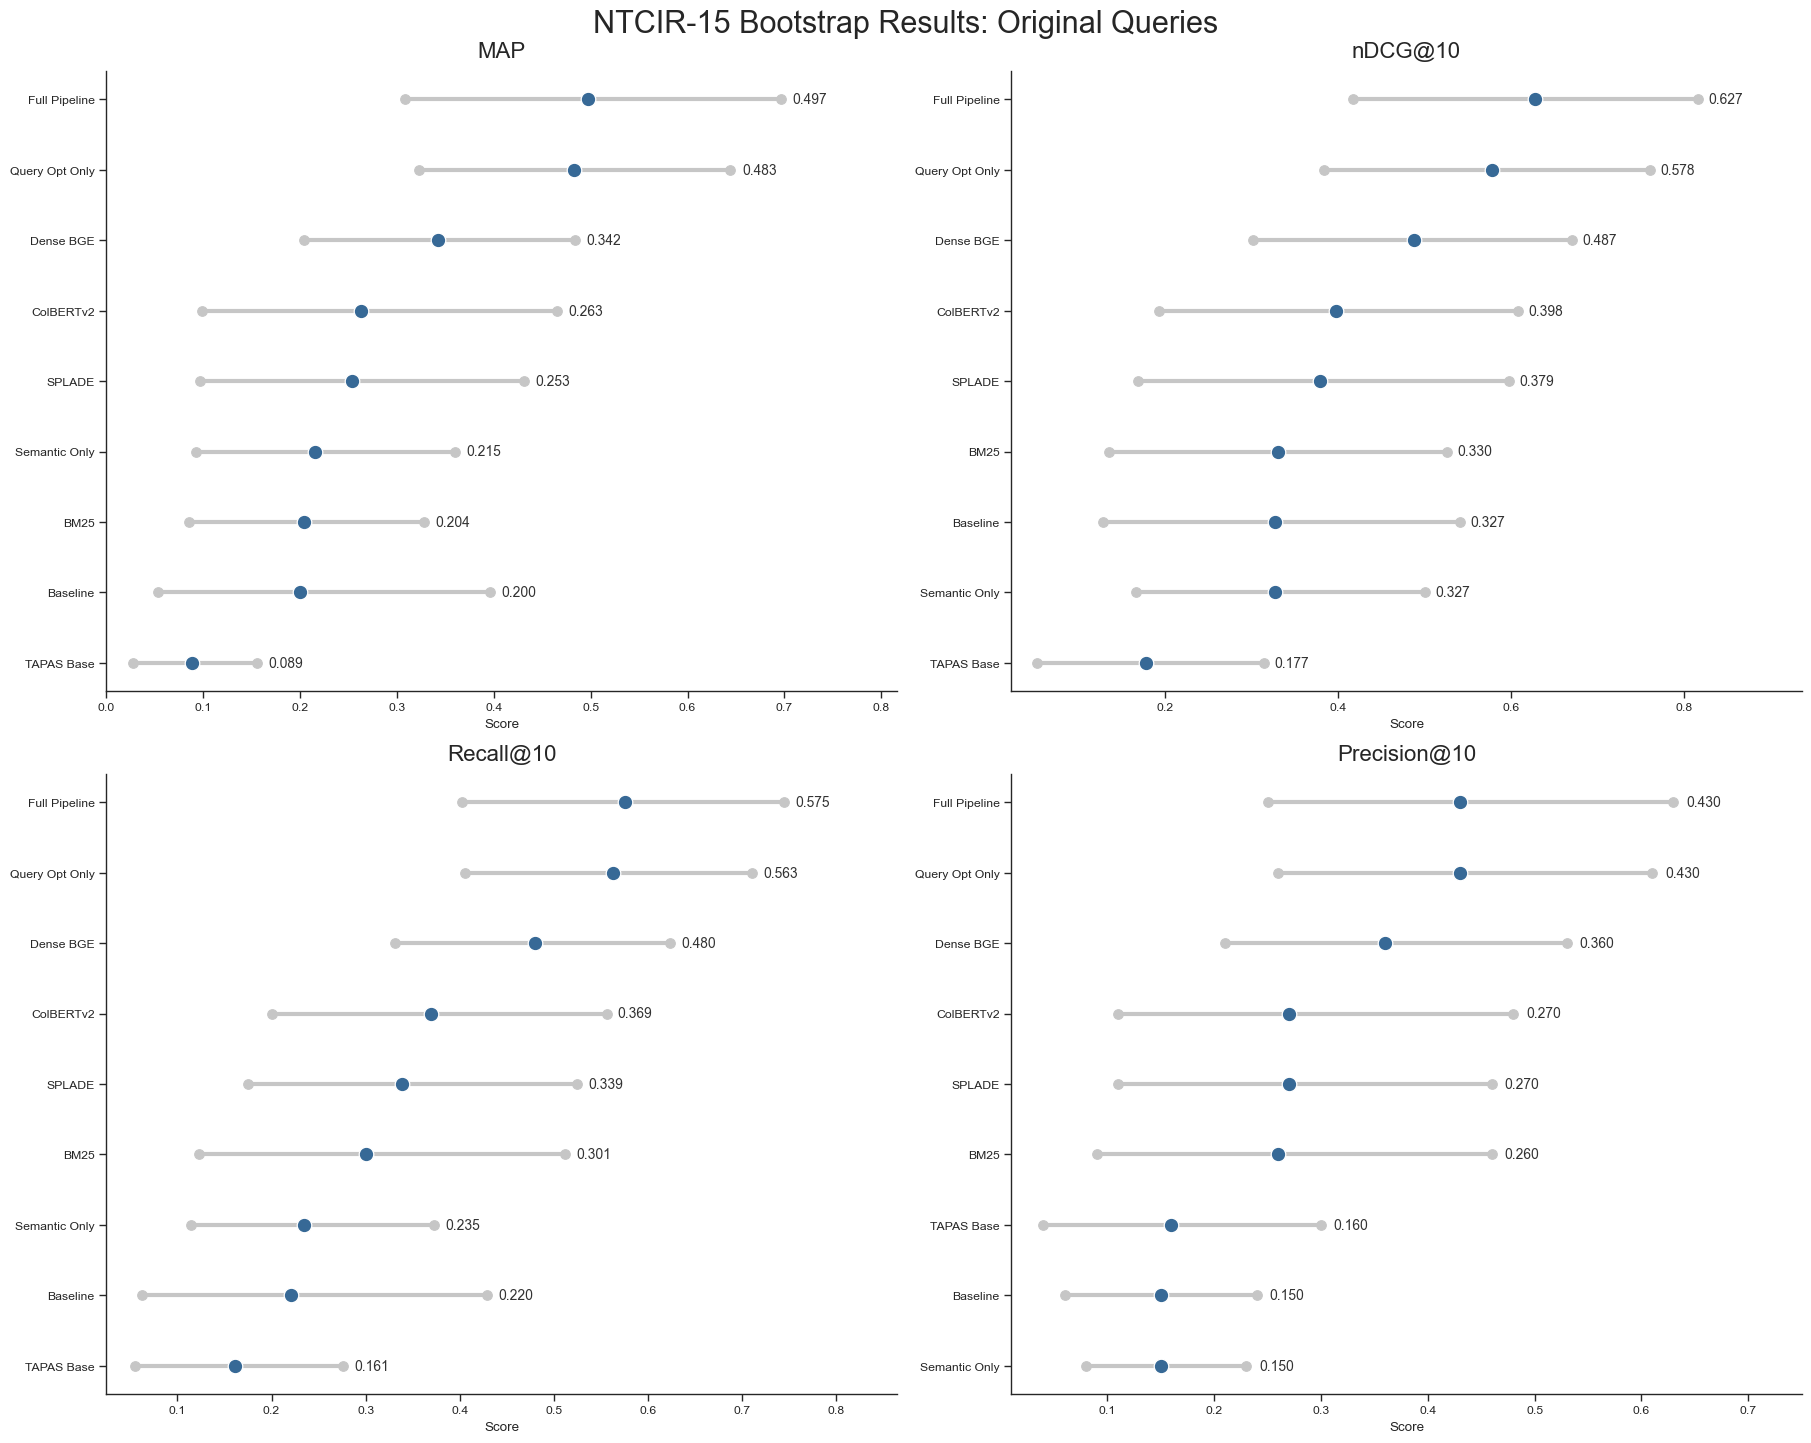

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14), constrained_layout=True)
for ax, metric_key in zip(axes.flat, METRICS):
    plot_variant_metric(ax, "original", metric_key)

fig.suptitle('NTCIR-15 Bootstrap Results: Original Queries', fontsize=22, y=1.02)
plt.show()


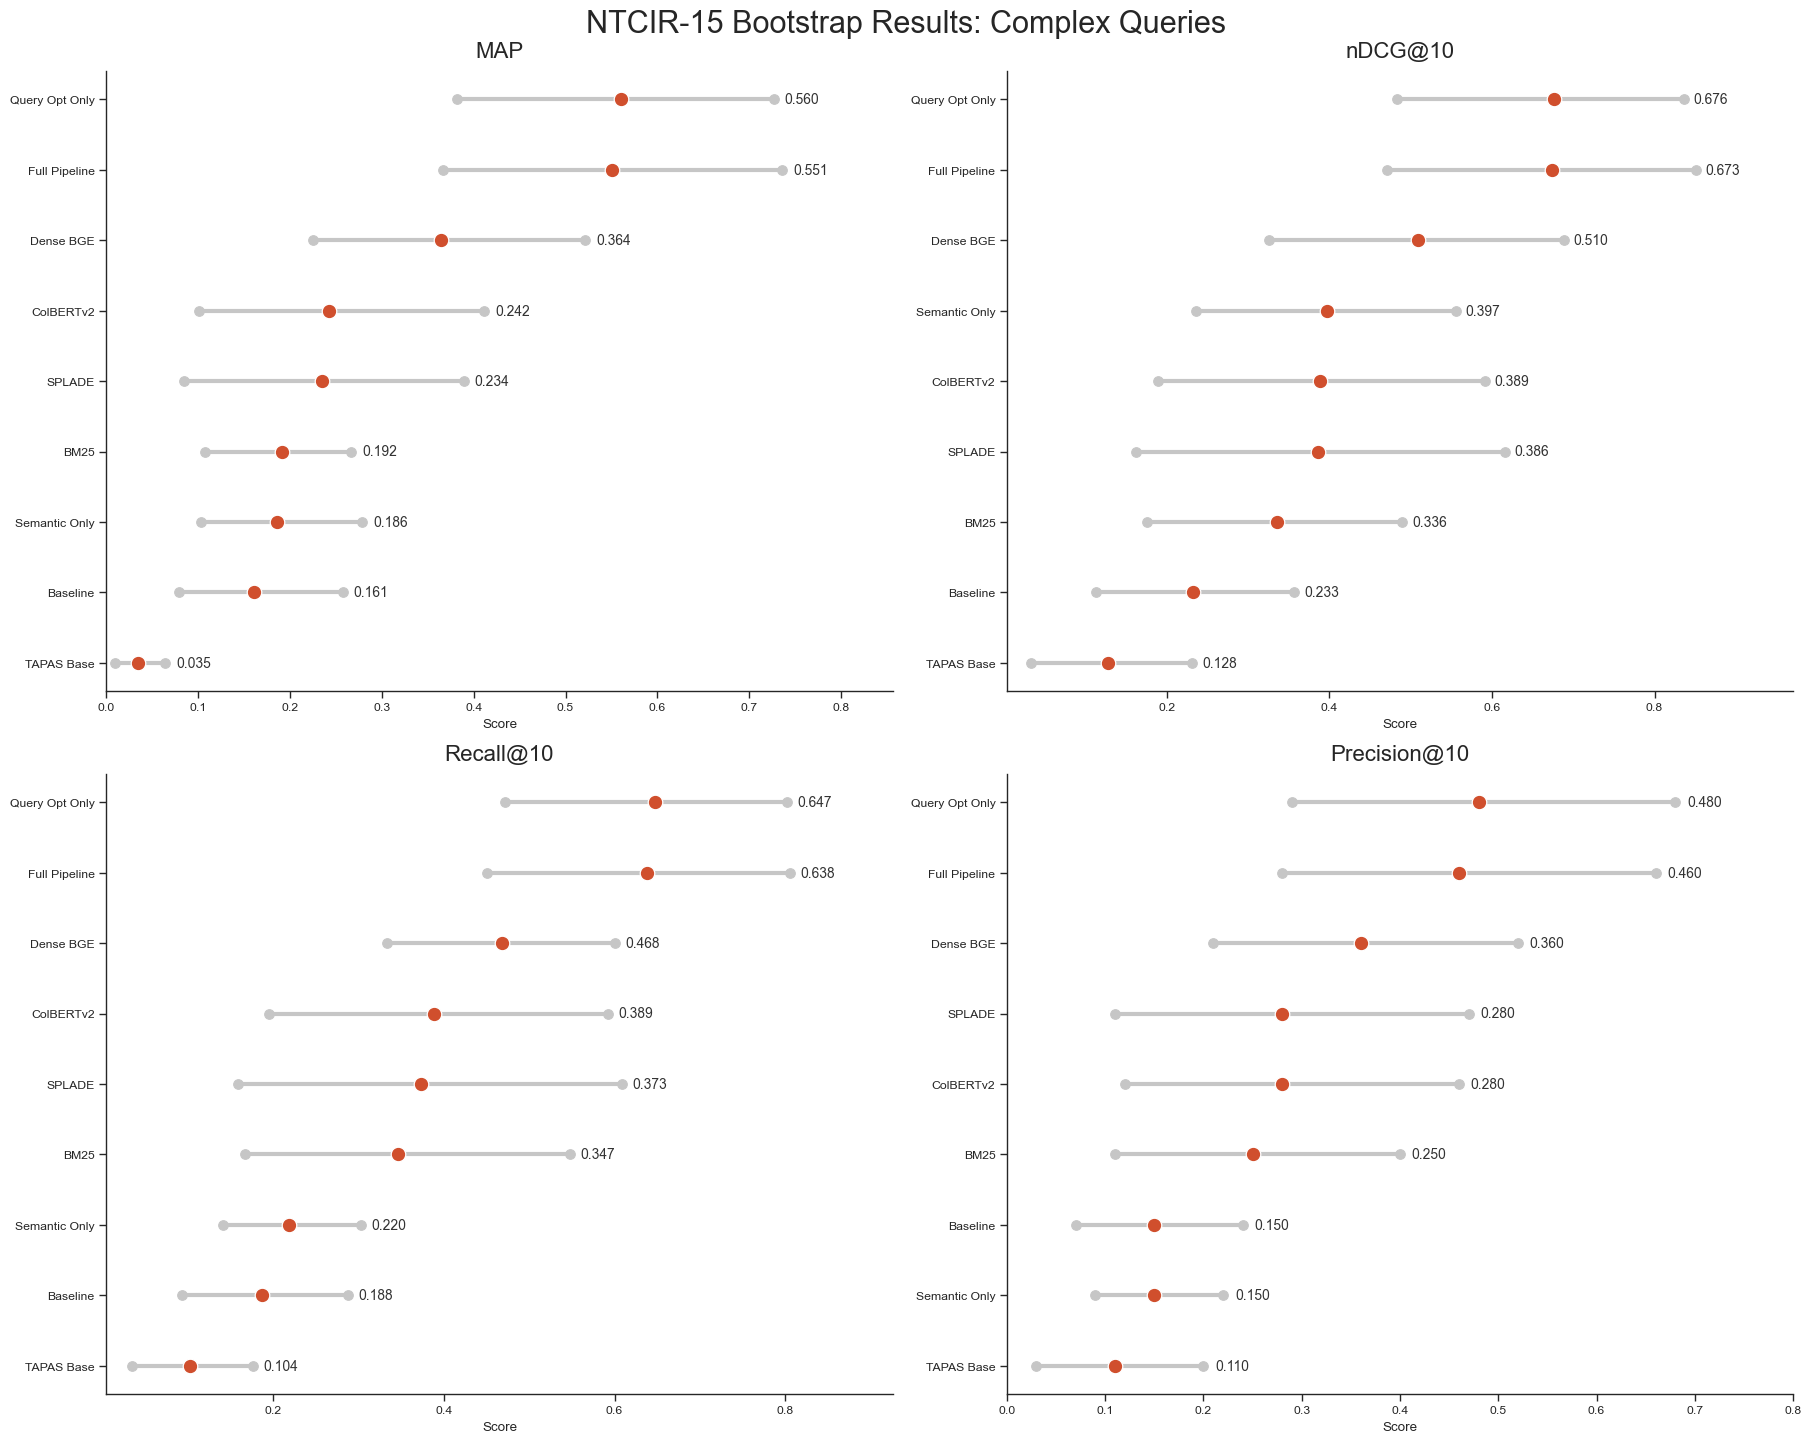

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14), constrained_layout=True)
for ax, metric_key in zip(axes.flat, METRICS):
    plot_variant_metric(ax, "complex", metric_key)

fig.suptitle('NTCIR-15 Bootstrap Results: Complex Queries', fontsize=22, y=1.02)
plt.show()


In [6]:
prepare_variant_metric_frame("original", "map")[["method_label", "point", "ci_low", "ci_high"]]


,method_label,point,ci_low,ci_high
0,TAPAS Base,0.088767,0.027185,0.155742
1,Baseline,0.199541,0.053030,0.395839
2,BM25,0.204233,0.085411,0.327987
3,Semantic Only,0.215064,0.092521,0.359509
4,SPLADE,0.253223,0.096787,0.430963
5,ColBERTv2,0.263019,0.098927,0.465129
6,Dense BGE,0.342250,0.203902,0.483896
7,Query Opt Only,0.483208,0.322976,0.644376
8,Full Pipeline,0.496991,0.308332,0.696118


In [7]:
prepare_variant_metric_frame("complex", "map")[["method_label", "point", "ci_low", "ci_high"]]


,method_label,point,ci_low,ci_high
0,TAPAS Base,0.034606,0.009524,0.063674
1,Baseline,0.161096,0.079386,0.257157
2,Semantic Only,0.185508,0.102997,0.278344
3,BM25,0.191712,0.107329,0.266754
4,SPLADE,0.234290,0.084818,0.389230
5,ColBERTv2,0.242297,0.100913,0.411720
6,Dense BGE,0.364291,0.224471,0.521346
7,Full Pipeline,0.550902,0.366329,0.736132
8,Query Opt Only,0.560301,0.381701,0.726587


## Compact Paper Figure

The following cells collapse the visualization into a single `2x2` figure. Each panel is one metric, and each method has two nearby horizontal CI dumbbells: `original` slightly below the row center and `complex` slightly above it.

This keeps both variants visually paired without collapsing the confidence intervals on top of each other.


In [13]:
METHOD_ORDER = (
    summary.groupby("method", as_index=False)[["map_point_estimate"]]
    .mean()
    .sort_values("map_point_estimate", ascending=True)["method"]
    .tolist()
)


def prepare_paired_metric_frame(metric_key: str) -> pd.DataFrame:
    metric_name, point_col, low_col, high_col = METRICS[metric_key]
    frame = summary[["variant", "method", "method_label", point_col, low_col, high_col]].copy()
    frame = frame.rename(columns={point_col: "point", low_col: "ci_low", high_col: "ci_high"})
    frame["metric_name"] = metric_name
    frame["method"] = pd.Categorical(frame["method"], categories=METHOD_ORDER, ordered=True)
    frame = frame.sort_values(["method", "variant"]).reset_index(drop=True)
    return frame


def plot_paired_metric(ax, metric_key: str) -> None:
    frame = prepare_paired_metric_frame(metric_key)
    methods = [method for method in METHOD_ORDER if method in set(frame["method"].astype(str))]
    y_base = {method: idx for idx, method in enumerate(methods)}
    y_offset = {"original": -0.14, "complex": 0.14}

    for method in methods:
        subset = frame.loc[frame["method"].astype(str) == method].copy()
        if len(subset) != 2:
            continue
        row_y = y_base[method]
        orig = subset.loc[subset["variant"] == "original"].iloc[0]
        comp = subset.loc[subset["variant"] == "complex"].iloc[0]
        ax.plot([orig["point"], comp["point"]], [row_y + y_offset["original"], row_y + y_offset["complex"]], color="#d0d0d0", lw=1.8, zorder=1)

        for variant, row in [("original", orig), ("complex", comp)]:
            y = row_y + y_offset[variant]
            color = VARIANT_COLORS[variant]
            ax.plot([row["ci_low"], row["ci_high"]], [y, y], color=color, alpha=0.35, lw=3.0, solid_capstyle="round", zorder=2)
            ax.scatter(row["point"], y, s=85, color=color, edgecolor="white", linewidth=0.8, zorder=3, label=variant.title() if row_y == 0 else None)

    metric_name = frame["metric_name"].iloc[0]
    method_labels = [METHOD_LABELS.get(method, method) for method in methods]
    ax.set_title(metric_name, fontsize=15, pad=10)
    ax.set_yticks(list(y_base.values()))
    ax.set_yticklabels(method_labels)
    ax.set_xlabel("Score")
    ax.set_ylabel("")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, loc="lower right")
    lower = max(0.0, float(frame["ci_low"].min()) - 0.03)
    upper = min(1.0, float(frame["ci_high"].max()) + 0.08)
    ax.set_xlim(lower, upper)
    ax.set_ylim(-0.6, len(methods) - 0.4)


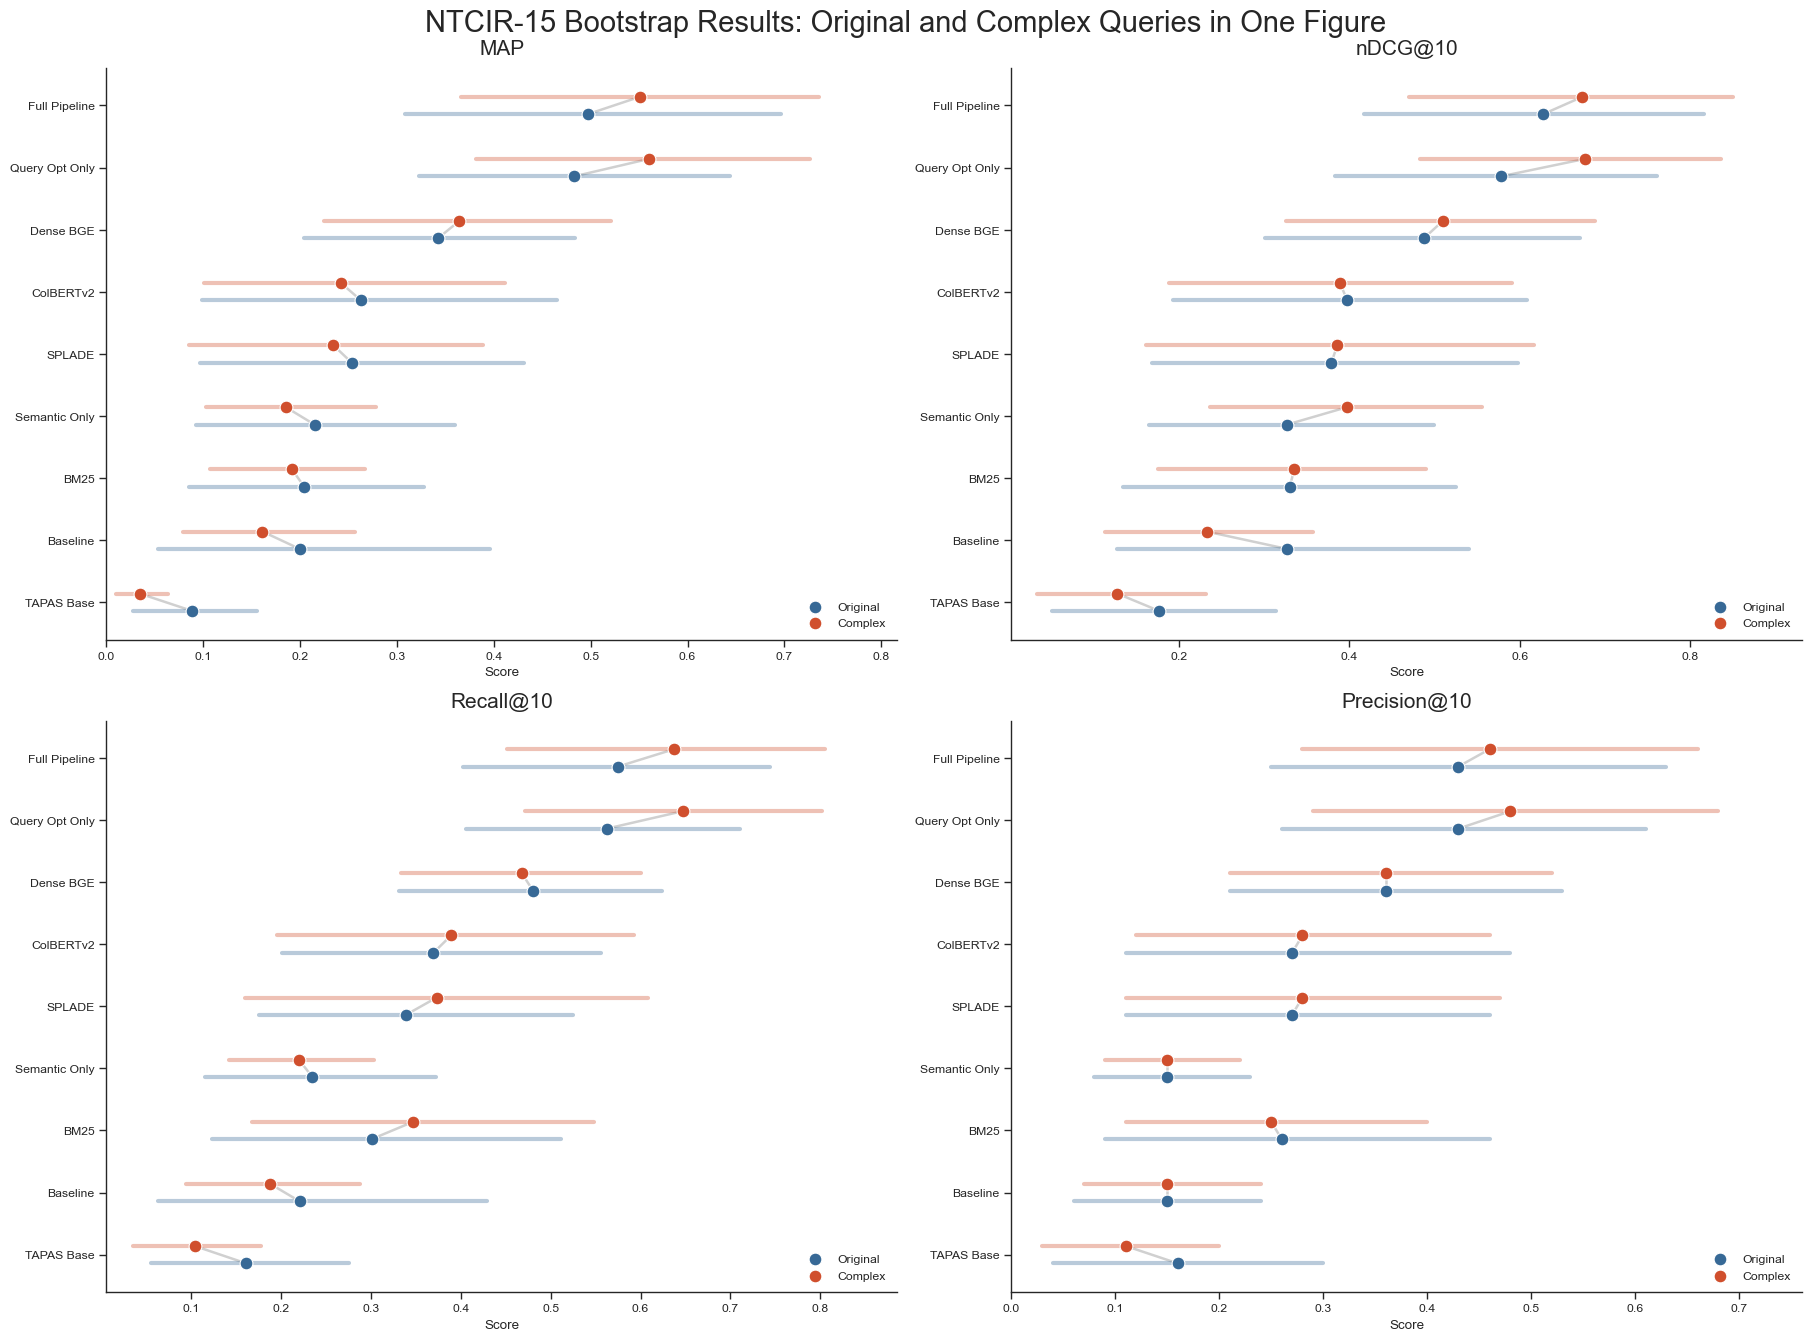

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13), constrained_layout=True)
for ax, metric_key in zip(axes.flat, METRICS):
    plot_paired_metric(ax, metric_key)

fig.suptitle('NTCIR-15 Bootstrap Results: Original and Complex Queries in One Figure', fontsize=21, y=1.02)
plt.show()


## Paper-Optimized Compact Figure

This version is tuned for limited paper space: shorter labels, lighter CI lines, smaller markers, one legend, and fixed x-limits per metric so the panels are easier to compare.


In [15]:
PAPER_METHOD_LABELS = {
    'baseline': 'Base',
    'bm25': 'BM25',
    'colbertv2': 'ColBERT',
    'dense_bge': 'BGE',
    'full': 'Full',
    'queryopt_only': 'QOpt',
    'semantic_only': 'Sem',
    'splade': 'SPLADE',
    'tapas_base': 'TAPAS',
}

PAPER_METRIC_LIMITS = {}
for metric_key, (_metric_name, point_col, low_col, high_col) in METRICS.items():
    low = max(0.0, float(summary[low_col].min()) - 0.02)
    high = min(1.0, float(summary[high_col].max()) + 0.05)
    PAPER_METRIC_LIMITS[metric_key] = (low, high)

PAPER_METHOD_ORDER = (
    summary.groupby("method", as_index=False)[["map_point_estimate"]]
    .mean()
    .sort_values("map_point_estimate", ascending=False)["method"]
    .tolist()
)


def prepare_paper_metric_frame(metric_key: str) -> pd.DataFrame:
    metric_name, point_col, low_col, high_col = METRICS[metric_key]
    frame = summary[["variant", "method", "method_label", point_col, low_col, high_col]].copy()
    frame = frame.rename(columns={point_col: "point", low_col: "ci_low", high_col: "ci_high"})
    frame["metric_name"] = metric_name
    frame["method"] = pd.Categorical(frame["method"], categories=PAPER_METHOD_ORDER, ordered=True)
    frame = frame.sort_values(["method", "variant"]).reset_index(drop=True)
    return frame


def plot_paper_metric(ax, metric_key: str, show_legend: bool = False) -> None:
    frame = prepare_paper_metric_frame(metric_key)
    methods = [method for method in PAPER_METHOD_ORDER if method in set(frame["method"].astype(str))]
    row_step = 0.82
    y_base = {method: idx * row_step for idx, method in enumerate(methods)}
    y_offset = {"original": -0.09, "complex": 0.09}

    for method in methods:
        subset = frame.loc[frame["method"].astype(str) == method].copy()
        if len(subset) != 2:
            continue
        row_y = y_base[method]
        orig = subset.loc[subset["variant"] == "original"].iloc[0]
        comp = subset.loc[subset["variant"] == "complex"].iloc[0]
        ax.plot([orig["point"], comp["point"]], [row_y + y_offset["original"], row_y + y_offset["complex"]], color="#d7d7d7", lw=1.0, zorder=1)
        for variant, row in [("original", orig), ("complex", comp)]:
            y = row_y + y_offset[variant]
            color = VARIANT_COLORS[variant]
            ax.plot([row["ci_low"], row["ci_high"]], [y, y], color=color, alpha=0.30, lw=2.0, solid_capstyle="round", zorder=2)
            ax.scatter(row["point"], y, s=42, color=color, edgecolor="white", linewidth=0.5, zorder=3, label=variant.title() if show_legend and row_y == 0 else None)

    metric_name = frame["metric_name"].iloc[0]
    method_labels = [PAPER_METHOD_LABELS.get(method, method) for method in methods]
    ax.set_title(metric_name, fontsize=12, pad=6)
    ax.set_yticks(list(y_base.values()))
    ax.set_yticklabels(method_labels, fontsize=9)
    ax.tick_params(axis="x", labelsize=9)
    ax.set_xlabel("Score", fontsize=10)
    ax.set_ylabel("")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", alpha=0.18)
    ax.grid(axis="y", visible=False)
    ax.set_xlim(*PAPER_METRIC_LIMITS[metric_key])
    upper_y = (len(methods) - 1) * row_step + 0.22 if methods else 0.22
    ax.set_ylim(-0.22, upper_y)
    if show_legend:
        ax.legend(frameon=False, loc="upper right", fontsize=9, handletextpad=0.4, borderaxespad=0.2)


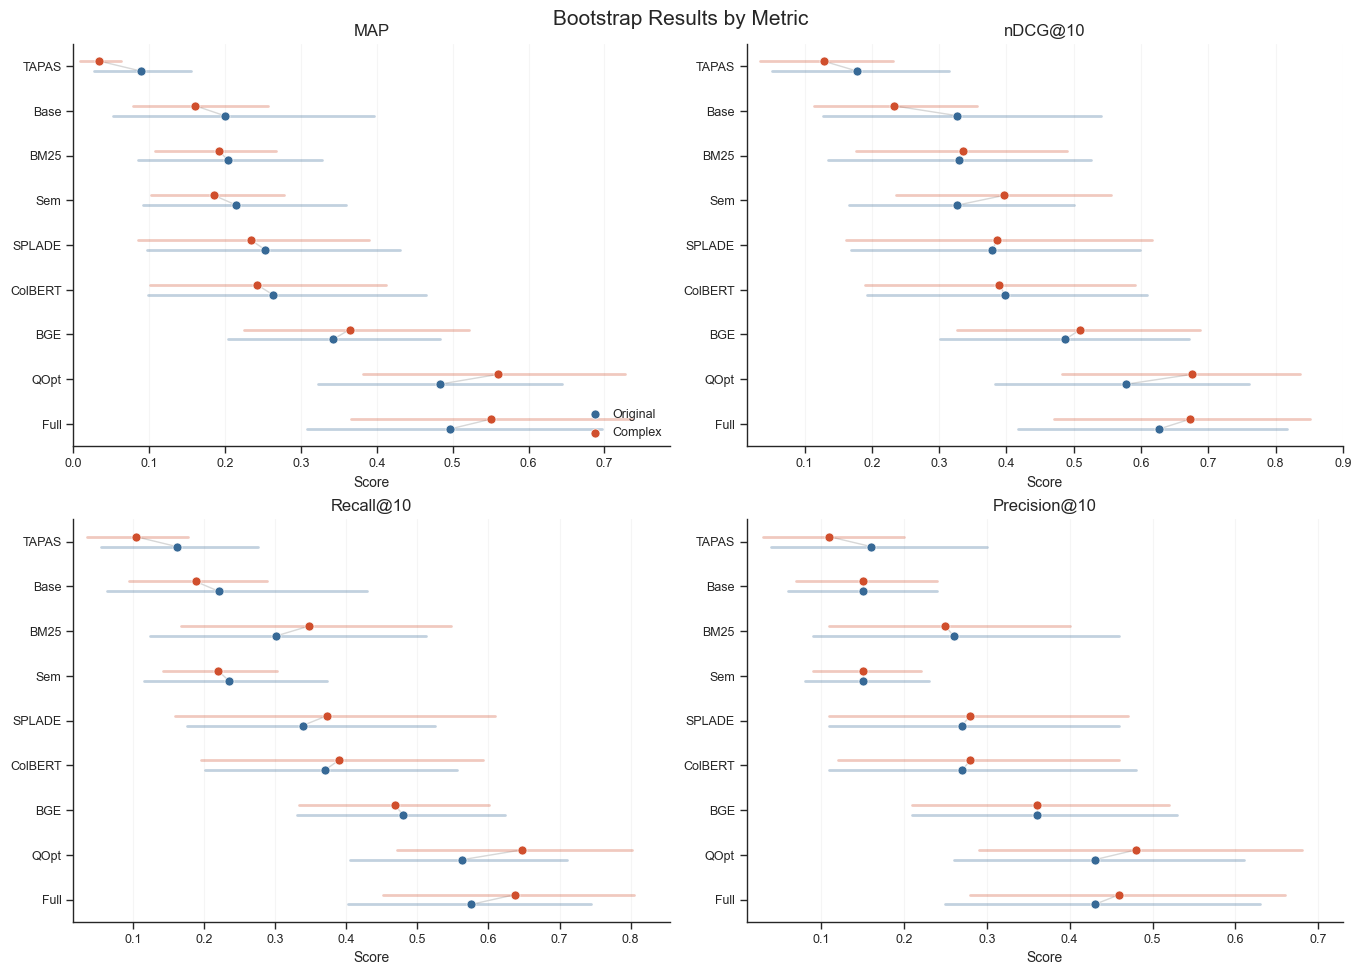

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.5), constrained_layout=True)
for idx, (ax, metric_key) in enumerate(zip(axes.flat, METRICS)):
    plot_paper_metric(ax, metric_key, show_legend=(idx == 0))

fig.suptitle('Bootstrap Results by Metric', fontsize=15, y=1.01)
plt.show()


## Paper-Compact nDCG@10 Only

This cell renders a paper-compact version of the paired plot for `nDCG@10` only.


In [ ]:
fig, ax = plt.subplots(figsize=(6.8, 5.6), constrained_layout=True)
plot_paper_metric(ax, "ndcg_cut_10", show_legend=True)
ax.set_title("")
fig.suptitle("Bootstrap Results: nDCG@10", fontsize=13, y=1.02)
plt.show()


## Export Compact nDCG@10 Figure

This cell saves the compact `nDCG@10` panel as a small, paper-ready PDF. PDF is vector-based, so it stays sharp without needing a large physical size.


In [ ]:
export_path = NOTEBOOK_DIR / "artifacts_live" / "eval_bootstrap" / "dumbbell_ndcg_paper_compact.pdf"
fig, ax = plt.subplots(figsize=(5.8, 4.0), constrained_layout=True)
plot_paper_metric(ax, "ndcg_cut_10", show_legend=True)
ax.set_title("")
fig.savefig(export_path, format="pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()
print(export_path)
